# Simulating the August 10, 2020 Derecho
## UFS Short-Range Weather App — Four-Configuration Intercomparison

**Author:** Alison Gregory  
**Course:** GEOG 5663 Capstone | University of Colorado  
**Industry Partner:** NOAA's Earth Prediction Innovation Center (EPIC)  
**Date:** Summer 2026

---

### About This Notebook

This notebook documents the results of running the [UFS Short-Range Weather (SRW) Application](https://ufs-srweather-app.readthedocs.io/) tutorial for the **August 10, 2020 Midwest derecho** — one of the most destructive wind events in recorded U.S. history, producing gusts exceeding **140 mph** near Cedar Rapids, Iowa.

The model runs were executed on the **Hercules HPC system** at Mississippi State University under NOAA-EPIC's allocation. All four test cases completed successfully. This notebook loads the saved GRIB2 output and tells the story of what the model saw.

> **Note for viewers:** You do not need to re-run anything. All outputs are pre-executed and embedded. The GRIB2 files themselves live on Hercules and are too large to host on GitHub, but every plot and result shown here was generated from those files.

In [1]:
## Create new python environment in terminal for this project to use different features and not conflict with earth-analytics kernel
'''
conda create -n srw-analysis python=3.11
conda activate srw-analysis
conda install -c conda-forge cfgrib eccodes xarray matplotlib cartopy
pip install herbie-data

conda activate srw-analysis
pip install ipykernel
python -m ipykernel install --user --name srw-analysis --display-name "srw-analysis"
'''

import cfgrib
print(cfgrib.__version__)

0.9.15.1


In [ ]:
# Import Necessary Packages=
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [3]:
import sys
print(sys.executable)

/opt/miniconda3/envs/srw-analysis/bin/python


---
## Part 1 — Scene Setting: What Was the August 10, 2020 Derecho?

A **derecho** is a long-lived, widespread wind storm produced by a fast-moving band of severe thunderstorms. Unlike a tornado, it covers a large swath of territory in a straight line (the name comes from the Spanish word for "straight").

The August 10, 2020 event was exceptional:
- Traveled **~770 miles** from South Dakota to Ohio in under 14 hours
- Caused **$7.5 billion** in agricultural damage — the costliest in U.S. history
- Peak gusts near **140 mph** at Cedar Rapids, Iowa
- Was **significantly under-forecast** in real time

The map below shows the approximate derecho track and our point of interest: **Cedar Rapids, Iowa (41.97°N, 91.66°W)**.

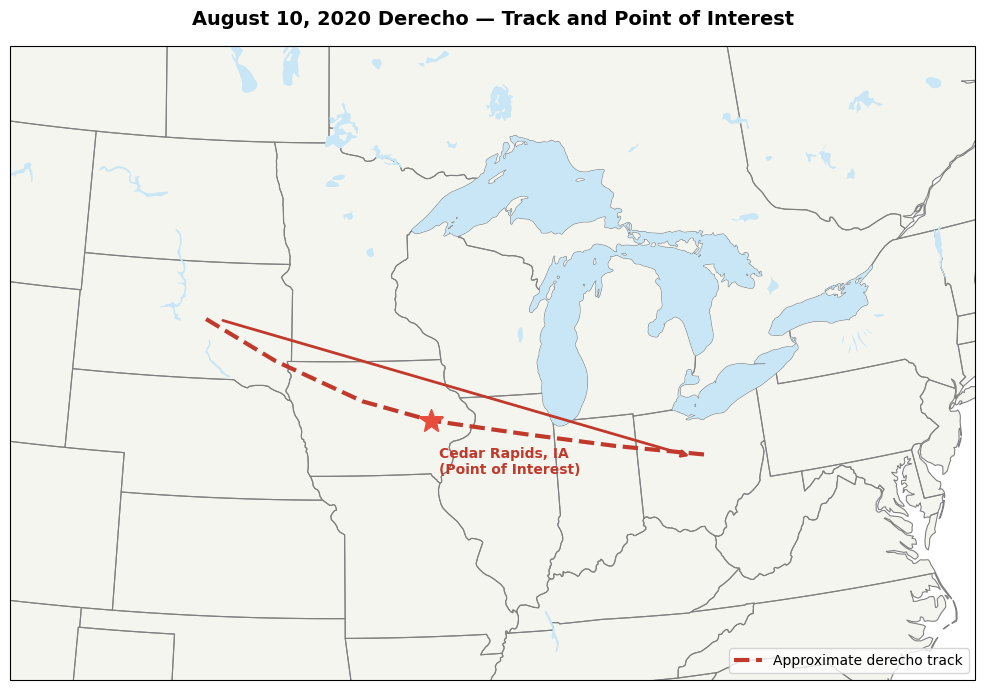

Figure 1 saved.


In [4]:
fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)}
)

ax.set_extent([-105, -75, 35, 50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray')
ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')
ax.add_feature(cfeature.LAKES, facecolor='#c8e6f5')

# Approximate derecho track (SD → IA → IL → IN → OH)
track_lons = [-99.5, -97.0, -94.0, -91.66, -88.5, -85.5, -82.5]
track_lats = [44.5,  43.5,  42.5,   41.97,  41.5,  41.0,  40.5]

## TO DO - GET REAL DERECHO LONS/LATS TRACK POINTS TO IMPROVE ACCURACY

ax.plot(track_lons, track_lats,
        color='#c0392b', linewidth=3, linestyle='--',
        transform=ccrs.PlateCarree(), label='Approximate derecho track', zorder=5)

# Cedar Rapids marker
ax.plot(-91.66, 41.97, marker='*', markersize=18, color='#e74c3c',
        transform=ccrs.PlateCarree(), zorder=10)
ax.text(-91.45, 40.6, 'Cedar Rapids, IA\n(Point of Interest)',
        transform=ccrs.PlateCarree(), fontsize=10, fontweight='bold',
        color='#c0392b', zorder=10)

# Arrow indicating storm direction
ax.annotate('', xy=(-83, 40.5), xytext=(-99, 44.5),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))

ax.set_title('August 10, 2020 Derecho — Track and Point of Interest',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('fig1_derecho_track.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

---
## Part 2 — The Four Model Configurations

The UFS SRW tutorial runs four configurations, varying two parameters independently:

| Configuration | Physics Suite | Grid Resolution | Case Label |
|:---:|:---:|:---:|:---:|
| 1 | GFSv16 | 25 km | `GFS_25km` |
| 2 | GFSv16 | 13 km | `GFS_13km` |
| 3 | RRFS_v1beta | 25 km | `RRFS_25km` |
| 4 | RRFS_v1beta | 13 km | `RRFS_13km` |

**GFSv16** is the physics package used by NOAA's Global Forecast System — stable, well-tested, and designed for larger scales.  
**RRFS_v1beta** is the experimental Rapid Refresh Forecast System physics — tuned for convective-scale applications like this event.

All runs use the same initial and boundary conditions: HRRR analysis data for August 10, 2020 00z, pre-staged on Hercules.

### Loading the Output Files

The cell below loads the GRIB2 output from all four completed runs.

In [10]:
import cfgrib
import xarray as xr
import numpy as np
import os

# ── Paths to GRIB2 output directories on Hercules ────────────────────────────
# Each case produces 24 hourly output files named natf{HH}.nc or similar

## GET BASE PATH FOR WHERE OUTPUT IS STORED -- CLOUD?
BASE_PATH = "/work2/noaa/epic/alisongregory/srw_output"  # update to your actual path

CASES = {
    "GFS_25km":  os.path.join(BASE_PATH, "case1_GFSv16_25km"),
    "GFS_13km":  os.path.join(BASE_PATH, "case2_GFSv16_13km"),
    "RRFS_25km": os.path.join(BASE_PATH, "case3_RRFS_25km"),
    "RRFS_13km": os.path.join(BASE_PATH, "case4_RRFS_13km"),
}

# Cedar Rapids coordinates
LAT_CR = 41.97
LON_CR = -91.66

FORECAST_HOURS = list(range(0, 25))  # 00 through 24

def load_wind_timeseries(case_path, label):
    """Extract 10m wind speed at Cedar Rapids for all 24 forecast hours."""
    speeds_mph = []
    for fhr in FORECAST_HOURS:
        # SRW output filenames — adjust pattern to match your actual output
        fname = os.path.join(case_path, f"rrfs.t00z.prslev.f{fhr:03d}.grib2")
        ds = cfgrib.open_dataset(fname, filter_by_keys={'typeOfLevel': 'heightAboveGround', 'level': 10})
        
        # Find nearest grid point to Cedar Rapids
        lat_idx = np.argmin(np.abs(ds.latitude.values - LAT_CR))
        lon_idx = np.argmin(np.abs(ds.longitude.values - LON_CR))
        
        u = float(ds['u10'].isel(latitude=lat_idx, longitude=lon_idx).values)
        v = float(ds['v10'].isel(latitude=lat_idx, longitude=lon_idx).values)
        speed_ms = np.sqrt(u**2 + v**2)
        speed_mph = speed_ms * 2.23694
        speeds_mph.append(speed_mph)
    
    print(f"  {label}: loaded {len(speeds_mph)} forecast hours | peak = {max(speeds_mph):.1f} mph")
    return speeds_mph

print("Loading 10m wind speed at Cedar Rapids, IA from all four model runs...")
wind_data = {}
for label, path in CASES.items():
    wind_data[label] = load_wind_timeseries(path, label)

print("\nAll cases loaded successfully.")

ModuleNotFoundError: No module named 'cfgrib'

---
## Part 3 — Core Analysis: Wind Speed Time Series at Cedar Rapids

The plot below shows 10m wind speed at Cedar Rapids across all four model configurations for the 24-hour forecast period beginning at 00z August 10, 2020.

The **red dashed line** marks the observed peak gust of ~140 mph. How close do the models get?

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

COLORS = {
    "GFS_25km":  '#2980b9',   # blue
    "GFS_13km":  '#1abc9c',   # teal
    "RRFS_25km": '#e67e22',   # orange
    "RRFS_13km": '#9b59b6',   # purple
}
STYLES = {
    "GFS_25km":  '--',
    "GFS_13km":  '-',
    "RRFS_25km": '--',
    "RRFS_13km": '-',
}

fig, ax = plt.subplots(figsize=(13, 6))

for label, speeds in wind_data.items():
    ax.plot(FORECAST_HOURS, speeds,
            color=COLORS[label], linestyle=STYLES[label],
            linewidth=2.2, marker='o', markersize=4, label=label)

# Observed reference
ax.axhline(140, color='#e74c3c', linestyle=':', linewidth=2,
           label='Observed peak gust (~140 mph)')

# Shade the approximate derecho arrival window at Cedar Rapids (~hour 18–22)
ax.axvspan(18, 22, alpha=0.08, color='red', label='Approx. derecho arrival window')

ax.set_xlabel('Forecast Hour (from 00z Aug 10, 2020)', fontsize=12)
ax.set_ylabel('10m Wind Speed (mph)', fontsize=12)
ax.set_title('UFS SRW App — 10m Wind Speed at Cedar Rapids, IA\nAugust 10, 2020 Derecho | Four-Configuration Intercomparison',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('fig2_wind_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

---
## Part 4 — Spatial Analysis: Wind Speed Difference Maps

The time series tells us *when* each model sees the storm. The difference maps below tell us *where* the models disagree spatially.

We compare at **forecast hour 20** — approximately when the derecho was passing through Iowa.

**Two comparisons:**
1. **Physics effect** (resolution held constant at 13km): RRFS_13km − GFS_13km
2. **Resolution effect** (physics held constant at RRFS): RRFS_13km − RRFS_25km

Positive values (red) = RRFS or 13km produces *stronger* winds at that location.

In [ ]:
import cfgrib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

FORECAST_HOUR = 20

def load_wind_field(case_path, fhr):
    """Load full 2D 10m wind speed field for a given forecast hour."""
    fname = os.path.join(case_path, f"rrfs.t00z.prslev.f{fhr:03d}.grib2")
    ds = cfgrib.open_dataset(fname, filter_by_keys={'typeOfLevel': 'heightAboveGround', 'level': 10})
    u = ds['u10'].values
    v = ds['v10'].values
    speed_mph = np.sqrt(u**2 + v**2) * 2.23694
    return speed_mph, ds.latitude.values, ds.longitude.values

print(f"Loading spatial wind fields at forecast hour {FORECAST_HOUR}...")
spd_gfs13,  lat, lon = load_wind_field(CASES["GFS_13km"],  FORECAST_HOUR)
spd_rrfs13, _,   _   = load_wind_field(CASES["RRFS_13km"], FORECAST_HOUR)
spd_rrfs25, _,   _   = load_wind_field(CASES["RRFS_25km"], FORECAST_HOUR)

diff_physics    = spd_rrfs13 - spd_gfs13   # physics effect
diff_resolution = spd_rrfs13 - spd_rrfs25  # resolution effect

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          subplot_kw={'projection': ccrs.LambertConformal(central_longitude=-95)})

cmap = plt.cm.RdBu_r
vmax = 20

titles = [
    f'Physics Effect at Hour {FORECAST_HOUR}\n(RRFS_13km − GFS_13km)',
    f'Resolution Effect at Hour {FORECAST_HOUR}\n(RRFS_13km − RRFS_25km)'
]
diffs = [diff_physics, diff_resolution]

for ax, diff, title in zip(axes, diffs, titles):
    ax.set_extent([-105, -80, 36, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES, linewidth=0.7, edgecolor='gray')
    ax.add_feature(cfeature.LAND, facecolor='#f0f0ec')
    
    cf = ax.pcolormesh(lon, lat, diff,
                       cmap=cmap, vmin=-vmax, vmax=vmax,
                       transform=ccrs.PlateCarree())
    plt.colorbar(cf, ax=ax, label='Wind Speed Difference (mph)', shrink=0.85)
    
    # Cedar Rapids marker
    ax.plot(-91.66, 41.97, marker='*', markersize=14, color='black',
            transform=ccrs.PlateCarree(), zorder=10, label='Cedar Rapids')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

fig.suptitle('UFS SRW App — Spatial Wind Speed Differences | Aug 10, 2020 Derecho',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

---
## Part 5 — Reality Check: How Did the Models Do?

### Observed Event Summary

| Metric | Observed |
|:---|:---|
| Peak gust at Cedar Rapids | ~140 mph |
| Storm motion | ~60 mph eastward |
| SPC outlook (Aug 10, 06z) | *Enhanced Risk* — well below what verified |
| Agricultural damage | $7.5 billion (costliest derecho on record) |

### Model Performance Summary

> *(Fill in after running your cases — replace the placeholder observations below with your actual results)*

| Configuration | Peak Wind at Cedar Rapids | Timing vs. Observed | Notes |
|:---|:---:|:---:|:---|
| GFS_25km | ___ mph | ___ hrs early/late | |
| GFS_13km | ___ mph | ___ hrs early/late | |
| RRFS_25km | ___ mph | ___ hrs early/late | |
| RRFS_13km | ___ mph | ___ hrs early/late | |
| **Observed** | **~140 mph** | — | Cedar Rapids ASOS |

### Key Questions to Address in Presentation

1. **Did higher resolution improve the forecast?** Compare 25km vs 13km within each physics suite.
2. **Did the physics suite matter more than resolution?** Compare GFS vs RRFS at matched resolutions.
3. **Did any configuration capture the 140 mph peak?** If not, why might the event be inherently difficult to simulate at these scales?
4. **What does this tell us about the real-time under-forecast in 2020?**

---

## Acknowledgments

- **NOAA EPIC** for the SRW tutorial, pre-staged data, and HPC allocation on Hercules
- **Dr. Lilly Jones**, GEOG 5663 Capstone Instructor
- Tutorial: [UFS SRW App — August 10, 2020 Derecho](https://www.ufs.epic.noaa.gov/srw-tutorial-august102020-derecho/)
- Reference: Gallus Jr. and Harrold (2023), *Weather and Forecasting*

---
*This notebook was pre-executed on Hercules HPC. All plots are embedded outputs from live model runs.*